Found roots (top 10 by Re):
s = +0.066313 +2.039497j, |det|=8.75e-14
s = +0.060918 +3.150551j, |det|=2.67e-11


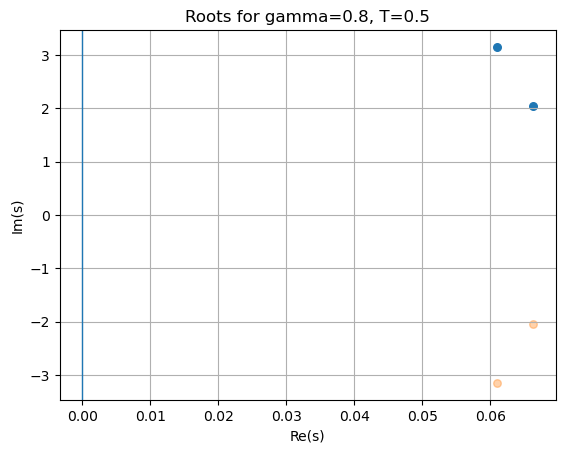

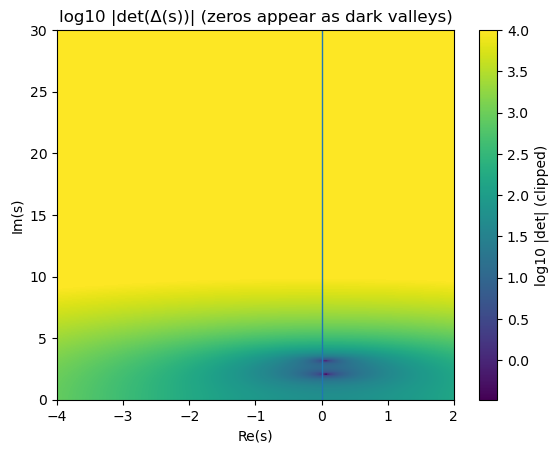

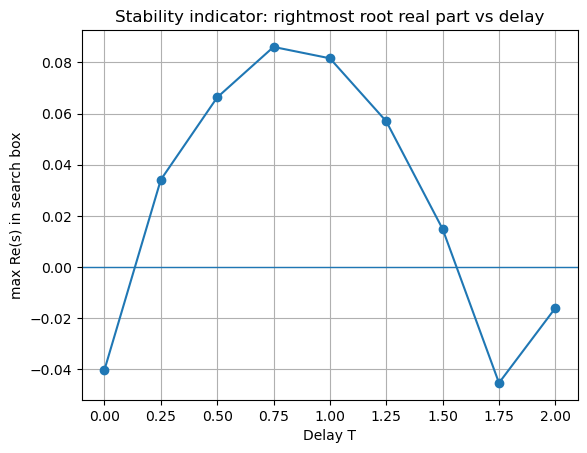

array([-0.04016035,  0.03414816,  0.06631302,  0.08605599,  0.08160571,
        0.05697384,  0.01488414, -0.04525372, -0.01597556])

In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.optimize import root

# ----------------------------
# Model definition (2 DOF)
# ----------------------------

@dataclass
class DDE2DOF:
    M: np.ndarray
    C: np.ndarray
    K: np.ndarray
    A: np.ndarray
    gamma: float
    T: float

    def char_matrix(self, s: complex) -> np.ndarray:
        """Characteristic matrix Δ(s) = Ms^2 + Cs + K - gamma*A*(1 - e^{-sT})."""
        return (self.M*(s**2) + self.C*s + self.K
                - self.gamma*self.A*(1.0 - np.exp(-s*self.T)))

    def det_delta(self, s: complex) -> complex:
        """det(Δ(s)) as complex scalar."""
        return la.det(self.char_matrix(s))

    def det_vec(self, z: np.ndarray) -> np.ndarray:
        """
        Real-vector form for solvers:
        z = [sigma, omega] represents s = sigma + i*omega
        returns [Re(det), Im(det)].
        """
        s = z[0] + 1j*z[1]
        d = self.det_delta(s)
        return np.array([d.real, d.imag])


# ----------------------------
# Example parameter set
# ----------------------------

def make_example(gamma=0.8, T=0.5):
    # Simple symmetric mechanical-ish matrices
    M = np.diag([1.0, 1.2])
    C = np.array([[0.08, 0.00],
                  [0.00, 0.10]])
    K = np.array([[10.0, -2.0],
                  [-2.0,  6.0]])

    # "Delay stiffness" coupling (choose something modest)
    A = np.array([[1.0, 0.2],
                  [0.2, 0.6]])

    return DDE2DOF(M=M, C=C, K=K, A=A, gamma=gamma, T=T)


# ----------------------------
# Root finding utilities
# ----------------------------

def find_roots_in_box(model: DDE2DOF,
                      sigma_range=(-4.0, 2.0),
                      omega_range=(0.0, 30.0),
                      n_grid=(12, 24),
                      tol=1e-8,
                      max_roots=200):
    """
    Brute-force seed grid + local solve to find multiple roots in a rectangular region.
    Returns unique roots (complex) with omega >= 0.
    """
    sigmas = np.linspace(*sigma_range, n_grid[0])
    omegas = np.linspace(*omega_range, n_grid[1])

    roots = []

    def add_root(s):
        # uniqueness check
        for r in roots:
            if abs(s - r) < 1e-3:
                return
        roots.append(s)

    for sigma in sigmas:
        for omega in omegas:
            z0 = np.array([sigma, omega], dtype=float)
            sol = root(model.det_vec, z0, method='hybr', tol=tol)
            if not sol.success:
                continue
            s = sol.x[0] + 1j*sol.x[1]
            if s.imag < -1e-6:
                continue
            # verify small residual
            res = model.det_delta(s)
            if abs(res) < 1e-6:
                add_root(s)
            if len(roots) >= max_roots:
                break

    # sort by real part (descending), then imag
    roots = sorted(roots, key=lambda z: (-z.real, z.imag))
    return np.array(roots, dtype=complex)


def rightmost_real_part(roots: np.ndarray):
    """Return max Re(s) among roots, or -inf if empty."""
    if roots.size == 0:
        return -np.inf
    return np.max(roots.real)


# ----------------------------
# Plotting helpers
# ----------------------------

def plot_root_map(roots, title="Characteristic roots (in search box)"):
    plt.figure()
    if roots.size:
        plt.scatter(roots.real, roots.imag, s=30)
        plt.scatter(roots.real, -roots.imag, s=30, alpha=0.35)  # mirror for visual symmetry
    plt.axvline(0.0, linewidth=1)
    plt.xlabel("Re(s)")
    plt.ylabel("Im(s)")
    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_logdet_contour(model: DDE2DOF,
                        sigma_range=(-4.0, 2.0),
                        omega_range=(0.0, 30.0),
                        n=(250, 250),
                        clip=( -8, 4 )):
    """
    Plot contour of log10|det(Δ(s))| over a grid in (sigma, omega).
    Zeros show up as deep "valleys".
    """
    sigmas = np.linspace(*sigma_range, n[0])
    omegas = np.linspace(*omega_range, n[1])
    Z = np.empty((n[1], n[0]), dtype=float)

    for j, w in enumerate(omegas):
        for i, sig in enumerate(sigmas):
            s = sig + 1j*w
            val = abs(model.det_delta(s))
            Z[j, i] = np.log10(val + 1e-30)

    plt.figure()
    extent = [sigmas[0], sigmas[-1], omegas[0], omegas[-1]]
    plt.imshow(np.clip(Z, *clip), origin='lower', aspect='auto', extent=extent)
    plt.axvline(0.0, linewidth=1)
    plt.xlabel("Re(s)")
    plt.ylabel("Im(s)")
    plt.title("log10 |det(Δ(s))| (zeros appear as dark valleys)")
    plt.colorbar(label="log10 |det| (clipped)")
    plt.grid(False)
    plt.show()


def scan_delay_and_plot(model_factory,
                        T_values,
                        sigma_range=(-4.0, 2.0),
                        omega_range=(0.0, 30.0),
                        n_grid=(10, 20)):
    """
    For each T, find roots in a box and plot max Re(s) vs T.
    """
    max_re = []
    for T in T_values:
        model = model_factory(T)
        roots = find_roots_in_box(model, sigma_range, omega_range, n_grid=n_grid)
        max_re.append(rightmost_real_part(roots))

    max_re = np.array(max_re)
    plt.figure()
    plt.plot(T_values, max_re, marker='o')
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Delay T")
    plt.ylabel("max Re(s) in search box")
    plt.title("Stability indicator: rightmost root real part vs delay")
    plt.grid(True)
    plt.show()

    return max_re


# ----------------------------
# Demo run
# ----------------------------

model = make_example(gamma=0.8, T=0.5)

roots = find_roots_in_box(model,
                          sigma_range=(-4, 2),
                          omega_range=(0, 30),
                          n_grid=(12, 24))

print("Found roots (top 10 by Re):")
for r in roots[:10]:
    print(f"s = {r.real:+.6f} {r.imag:+.6f}j, |det|={abs(model.det_delta(r)):.2e}")

plot_root_map(roots, title=f"Roots for gamma={model.gamma}, T={model.T}")

plot_logdet_contour(model, sigma_range=(-4, 2), omega_range=(0, 30), n=(250, 250))

# Scan delay
T_vals = np.linspace(0.0, 2.0, 9)
scan_delay_and_plot(lambda T: make_example(gamma=0.8, T=T),
                    T_vals,
                    sigma_range=(-6, 2),
                    omega_range=(0, 40),
                    n_grid=(10, 20))


Rightmost root Re(s): -inf
Top 8 roots by Re(s):


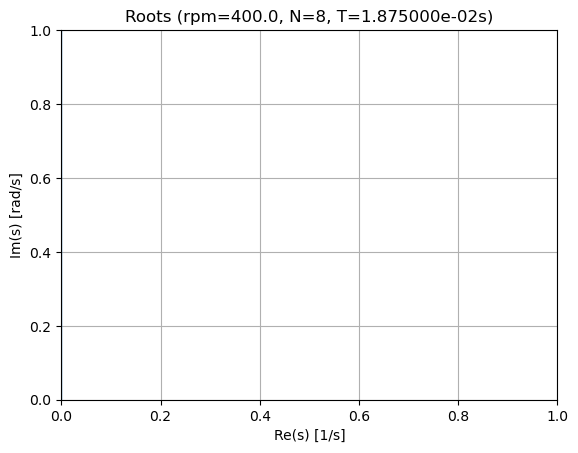

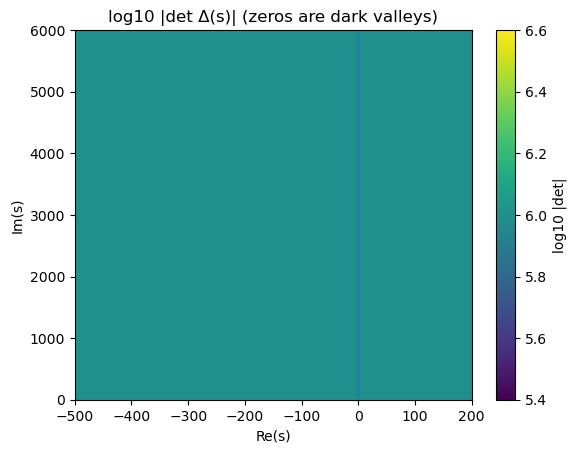

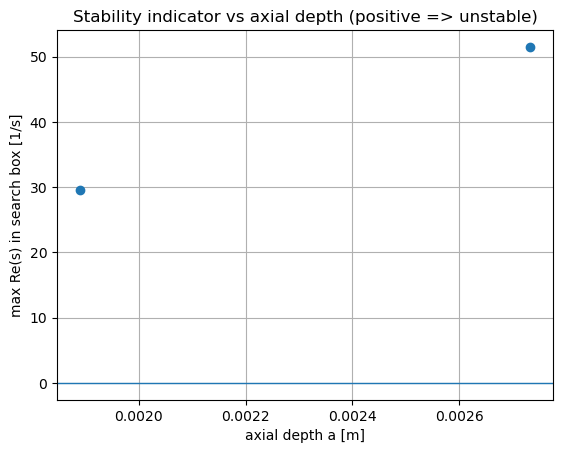

array([       -inf,        -inf,        -inf,        -inf, 29.62961007,
              -inf, 51.4873322 ,        -inf,        -inf,        -inf])

In [ ]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.optimize import root

# -----------------------------
# 1) Your measured M,C,K (SI)
# -----------------------------
M2 = np.array([[215.64254037, -21.55407231],
               [-21.55407231, 147.49265873]])

C2 = np.array([[2.77263850e+03,  1.01081932e-12],
               [-4.91643992e-13, 1.13023795e+03]])

K2 = np.array([[4.29769889e+06, -1.49937401e-08],
               [-6.49949346e-10, 4.60912641e+05]])

# -----------------------------
# 2) Altintas average A0(=mean directional matrix)
#    (Eq. 4.86 and definitions of alpha_ij)
# -----------------------------
def mean_directional_matrix_A0(phi_st, phi_ex, Kr, N_teeth):
    """
    Zero-order (average) directional matrix A0.
    Uses Altintas Eq. 4.86 with alpha_xx, alpha_xy, alpha_yx, alpha_yy
    evaluated between entry/exit angles.
    Angles in radians.
    """
    def alpha_xx(phi): return 0.5*( np.cos(2*phi) - 2*Kr*phi + Kr*np.sin(2*phi) )
    def alpha_xy(phi): return 0.5*( -np.sin(2*phi) - 2*phi + Kr*np.cos(2*phi) )
    def alpha_yx(phi): return 0.5*( -np.sin(2*phi) + 2*phi + Kr*np.cos(2*phi) )
    def alpha_yy(phi): return 0.5*( -np.cos(2*phi) - 2*Kr*phi - Kr*np.sin(2*phi) )

    axx = alpha_xx(phi_ex) - alpha_xx(phi_st)
    axy = alpha_xy(phi_ex) - alpha_xy(phi_st)
    ayx = alpha_yx(phi_ex) - alpha_yx(phi_st)
    ayy = alpha_yy(phi_ex) - alpha_yy(phi_st)

    # Eq. 4.86 has scaling N/(2π)
    A0 = (N_teeth/(2*np.pi)) * np.array([[axx, axy],
                                        [ayx, ayy]], dtype=float)
    return A0

# -----------------------------
# 3) Tooth period
# -----------------------------
def T_period(rpm, N_teeth):
    # tooth passing frequency = rpm/60 * N_teeth
    return 60.0/(rpm * N_teeth)

# -----------------------------
# 4) Characteristic determinant for zero-order DDE
#    Δ(s) = Ms^2 + Cs + K - (1/2) a Kt A0 (1 - e^{-sT})
# -----------------------------
@dataclass
class MillingZeroOrder:
    M: np.ndarray
    C: np.ndarray
    K: np.ndarray
    A0: np.ndarray
    Kt: float      # tangential cutting coeff [N/m^2] or equivalent consistent units
    a: float       # axial depth of cut [m]
    T: float       # tooth period [s]

    def delta(self, s: complex) -> np.ndarray:
        gain = 0.5 * self.a * self.Kt
        return self.M*(s**2) + self.C*s + self.K - gain*self.A0*(1.0 - np.exp(-s*self.T))

    def det_delta(self, s: complex) -> complex:
        return la.det(self.delta(s))

    def det_vec(self, z):
        s = z[0] + 1j*z[1]
        d = self.det_delta(s)
        return np.array([d.real, d.imag])

# -----------------------------
# 5) Root search in a rectangle (sigma, omega)
# -----------------------------
def find_roots_in_box(model, sigma_range=(-500, 200), omega_range=(0, 6000),
                      n_grid=(18, 30), tol=1e-10, dedup=1e-1, max_roots=500):
    sigmas = np.linspace(*sigma_range, n_grid[0])
    omegas = np.linspace(*omega_range, n_grid[1])

    roots = []

    def add_root(s):
        for r in roots:
            if abs(s-r) < dedup:
                return
        roots.append(s)

    for sig in sigmas:
        for om in omegas:
            sol = root(model.det_vec, np.array([sig, om]), method="hybr", tol=tol)
            if not sol.success:
                continue
            s = sol.x[0] + 1j*sol.x[1]
            if s.imag < -1e-6:
                continue
            if abs(model.det_delta(s)) < 1e-6:
                add_root(s)
            if len(roots) >= max_roots:
                break

    roots = sorted(roots, key=lambda z: (-z.real, z.imag))
    return np.array(roots, dtype=complex)

# -----------------------------
# 6) Plot helpers
# -----------------------------
def plot_root_map(roots, title="Characteristic roots"):
    plt.figure()
    if roots.size:
        plt.scatter(roots.real, roots.imag, s=22)
        plt.scatter(roots.real, -roots.imag, s=22, alpha=0.25)
    plt.axvline(0.0, linewidth=1)
    plt.xlabel("Re(s) [1/s]")
    plt.ylabel("Im(s) [rad/s]")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_logdet_contour(model, sigma_range=(-500, 200), omega_range=(0, 6000), n=(350, 350), clip=(-10, 6)):
    sigmas = np.linspace(*sigma_range, n[0])
    omegas = np.linspace(*omega_range, n[1])
    Z = np.empty((n[1], n[0]))

    for j, w in enumerate(omegas):
        for i, sig in enumerate(sigmas):
            s = sig + 1j*w
            Z[j, i] = np.log10(abs(model.det_delta(s)) + 1e-30)

    plt.figure()
    extent = [sigmas[0], sigmas[-1], omegas[0], omegas[-1]]
    plt.imshow(np.clip(Z, *clip), origin="lower", aspect="auto", extent=extent)
    plt.axvline(0.0, linewidth=1)
    plt.xlabel("Re(s)")
    plt.ylabel("Im(s)")
    plt.title("log10 |det Δ(s)| (zeros are dark valleys)")
    plt.colorbar(label="log10 |det|")
    plt.show()

def rightmost_real_part(roots):
    return np.max(roots.real) if roots.size else -np.inf

def scan_depth_of_cut(make_model, a_values, root_box, n_grid=(14, 24)):
    max_re = []
    for a in a_values:
        mdl = make_model(a)
        roots = find_roots_in_box(mdl, **root_box, n_grid=n_grid)
        max_re.append(rightmost_real_part(roots))
    max_re = np.array(max_re)

    plt.figure()
    plt.plot(a_values, max_re, marker="o")
    plt.axhline(0, linewidth=1)
    plt.xlabel("axial depth a [m]")
    plt.ylabel("max Re(s) in search box [1/s]")
    plt.title("Stability indicator vs axial depth (positive => unstable)")
    plt.grid(True)
    plt.show()
    return max_re

# -----------------------------
# 7) Example wiring with your milling params
# -----------------------------
# YOU must supply:
#   phi_st, phi_ex (radians)
#   Kt (SI)
#   Kr = Krc/Ktc (dimensionless)
phi_st = 0.0
phi_ex = np.pi/2   # just placeholder, replace with your compute_entry_exit_angles_downmilling

Ktc = 1930.4
Krc = 1159.6

Ktc_SI = Ktc * 1e6     # placeholder; replace with your Ktc * 1e6
Krc_SI = Krc * 1e6     # placeholder; replace with your Krc * 1e6
Kr = Krc_SI / Ktc_SI

N_teeth = 8
rpm_fixed = 400.0
T = T_period(rpm_fixed, N_teeth)

A0 = mean_directional_matrix_A0(phi_st, phi_ex, Kr, N_teeth)

def make_model(a):
    return MillingZeroOrder(M=M2, C=C2, K=K2, A0=A0, Kt=Ktc_SI, a=a, T=T)

mdl = make_model(a=5.0e-3)  # 1 mm axial depth

roots = find_roots_in_box(mdl,
                          sigma_range=(-500, 200),
                          omega_range=(0, 6000),
                          n_grid=(18, 30))

print("Rightmost root Re(s):", rightmost_real_part(roots))
print("Top 8 roots by Re(s):")
for r in roots[:8]:
    print(f"s = {r.real:+.3f} {r.imag:+.3f}j")

plot_root_map(roots, title=f"Roots (rpm={rpm_fixed}, N={N_teeth}, T={T:.6e}s)")
plot_logdet_contour(mdl, sigma_range=(-500, 200), omega_range=(0, 6000))

# scan axial depth
a_vals = np.linspace(0.2e-3, 4.0e-3, 10)  # 0.2mm..4mm
root_box = dict(sigma_range=(-500, 200), omega_range=(0, 6000))
scan_depth_of_cut(make_model, a_vals, root_box=root_box)


In [8]:
from scipy.optimize import brentq

def stability_indicator_maxRe(make_model, a,
                              root_box,
                              n_grid=(14, 24)):
    """
    Returns g(a) = max Re(s) among roots found in the search box.
    Positive => unstable (at least one root with Re>0).
    """
    mdl = make_model(a)
    roots = find_roots_in_box(mdl, **root_box, n_grid=n_grid)
    return rightmost_real_part(roots)


def find_a_limit(make_model,
                 a_min=0.0,
                 a_max=6e-3,
                 n_scan=20,
                 root_box=None,
                 n_grid_scan=(12, 20),
                 n_grid_refine=(18, 28),
                 verbose=True):
    """
    Finds the smallest a in [a_min,a_max] where maxRe crosses 0.
    Returns (a_limit, scan_a, scan_g). If no crossing, a_limit=None.
    """
    if root_box is None:
        root_box = dict(sigma_range=(-500, 200), omega_range=(0, 6000))

    # coarse scan
    scan_a = np.linspace(a_min, a_max, n_scan)
    scan_g = np.array([
        stability_indicator_maxRe(make_model, a, root_box, n_grid=n_grid_scan)
        for a in scan_a
    ])

    # find first sign change from negative to positive
    idx = None
    for k in range(len(scan_a) - 1):
        if scan_g[k] <= 0 and scan_g[k+1] > 0:
            idx = k
            break

    if idx is None:
        if verbose:
            print("No stability boundary found in the scan range.")
            print(f"min g(a)={scan_g.min():.3g}, max g(a)={scan_g.max():.3g}")
        return None, scan_a, scan_g

    aL, aU = scan_a[idx], scan_a[idx+1]

    if verbose:
        print(f"Bracket found: a in [{aL:.3e}, {aU:.3e}] m "
              f"with g(aL)={scan_g[idx]:+.3g}, g(aU)={scan_g[idx+1]:+.3g}")

    # refinement: define a slightly more accurate g(a) for brentq
    def g(a):
        return stability_indicator_maxRe(make_model, a, root_box, n_grid=n_grid_refine)

    # Brent's method (robust)
    a_lim = brentq(g, aL, aU, xtol=1e-8, rtol=1e-8, maxiter=40)

    if verbose:
        print(f"a_limit ≈ {a_lim:.6e} m  ({a_lim*1e3:.4f} mm)")

    return a_lim, scan_a, scan_g

def plot_a_limit_scan(scan_a, scan_g, a_lim=None, title="Stability boundary vs axial depth"):
    plt.figure()
    plt.plot(scan_a*1e3, scan_g, marker="o")  # mm on x-axis
    plt.axhline(0.0, linewidth=1)
    if a_lim is not None:
        plt.axvline(a_lim*1e3, linestyle="--", linewidth=1)
        plt.text(a_lim*1e3, 0.0, f"  a_lim={a_lim*1e3:.3f} mm", va="bottom")
    plt.xlabel("axial depth a [mm]")
    plt.ylabel("g(a)=max Re(s) [1/s] (positive => unstable)")
    plt.title(title)
    plt.grid(True)
    plt.show()



Bracket found: a in [2.471e-03, 2.824e-03] m with g(aL)=-inf, g(aU)=+53.4
a_limit ≈ 2.823524e-03 m  (2.8235 mm)


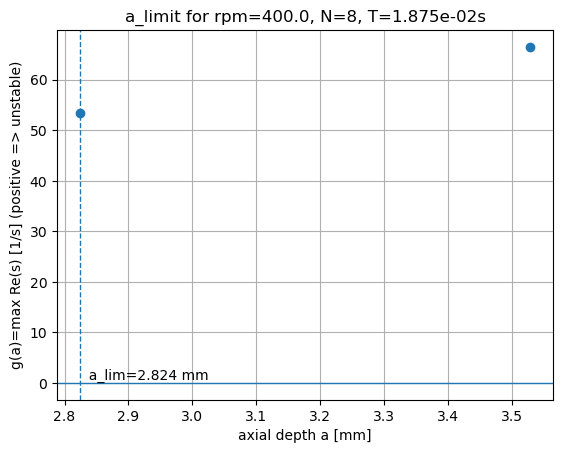

In [9]:
root_box = dict(
    sigma_range=(-800, 200),   # widen if needed
    omega_range=(0, 9000)      # widen if needed
)

a_lim, scan_a, scan_g = find_a_limit(
    make_model,
    a_min=0.0,
    a_max=6e-3,      # 0..6 mm
    n_scan=18,
    root_box=root_box,
    n_grid_scan=(12, 20),
    n_grid_refine=(18, 30),
    verbose=True
)

plot_a_limit_scan(scan_a, scan_g, a_lim,
                  title=f"a_limit for rpm={rpm_fixed}, N={N_teeth}, T={T:.3e}s")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_a_limit_for_rpm(
    rpm,
    make_model_for_T,          # function (T)->(make_model(a))
    a_min=0.0,
    a_max=6e-3,
    n_scan=10,
    root_box=None,
    n_grid_scan=(8, 14),
    n_grid_refine=(10, 16),
    refine=True,
    verbose=False,
):
    """
    Returns a_limit (float or np.nan) for a given rpm.
    """
    if rpm <= 1e-6:
        return np.nan  # undefined at 0 rpm (T infinite)

    if root_box is None:
        root_box = dict(sigma_range=(-800, 200), omega_range=(0, 9000))

    # build make_model(a) for this rpm (through T)
    make_model = make_model_for_T(rpm)

    # coarse scan to bracket
    scan_a = np.linspace(a_min, a_max, n_scan)
    scan_g = np.array([
        stability_indicator_maxRe(make_model, a, root_box, n_grid=n_grid_scan)
        for a in scan_a
    ])

    # find first crossing (stable -> unstable)
    idx = None
    for k in range(len(scan_a) - 1):
        if scan_g[k] <= 0 and scan_g[k+1] > 0:
            idx = k
            break

    if idx is None:
        if verbose:
            print(f"rpm={rpm:.0f}: no crossing in [{a_min},{a_max}] m; "
                  f"g min={scan_g.min():+.3g}, g max={scan_g.max():+.3g}")
        return np.nan

    aL, aU = scan_a[idx], scan_a[idx+1]

    if not refine:
        # rough estimate: linear interpolation on g
        gL, gU = scan_g[idx], scan_g[idx+1]
        a_est = aL + (0 - gL) * (aU - aL) / (gU - gL + 1e-30)
        return float(a_est)

    # refine with brent (recompute g with slightly finer root search)
    from scipy.optimize import brentq

    def g(a):
        return stability_indicator_maxRe(make_model, a, root_box, n_grid=n_grid_refine)

    try:
        a_lim = brentq(g, aL, aU, xtol=1e-7, rtol=1e-7, maxiter=25)
        return float(a_lim)
    except Exception as e:
        if verbose:
            print(f"rpm={rpm:.0f}: refine failed ({e}); using interpolation")
        gL, gU = scan_g[idx], scan_g[idx+1]
        a_est = aL + (0 - gL) * (aU - aL) / (gU - gL + 1e-30)
        return float(a_est)


def sweep_lobe_zero_order(
    rpm_values,
    N_teeth,
    phi_st, phi_ex,
    Ktc_SI, Krc_SI,
    M2, C2, K2,
    a_max=6e-3,
    root_box=None,
    n_scan=10,
    n_grid_scan=(8, 14),
    n_grid_refine=(10, 16),
    refine=True,
    progress_every=5
):
    """
    Sweeps a_limit(rpm) using the zero-order directional matrix A0.
    Returns arrays (rpm_values, a_limits).
    """

    Kr = Krc_SI / Ktc_SI
    A0 = mean_directional_matrix_A0(phi_st, phi_ex, Kr, N_teeth)

    def make_model_for_rpm(rpm):
        T = T_period(rpm, N_teeth)

        def make_model(a):
            return MillingZeroOrder(M=M2, C=C2, K=K2, A0=A0, Kt=Ktc_SI, a=a, T=T)

        return make_model

    a_limits = np.empty_like(rpm_values, dtype=float)
    for i, rpm in enumerate(rpm_values):
        a_lim = compute_a_limit_for_rpm(
            rpm,
            make_model_for_T=lambda rpm_: make_model_for_rpm(rpm_),
            a_min=0.0,
            a_max=a_max,
            n_scan=n_scan,
            root_box=root_box,
            n_grid_scan=n_grid_scan,
            n_grid_refine=n_grid_refine,
            refine=refine,
            verbose=False
        )
        a_limits[i] = a_lim

        if progress_every and (i % progress_every == 0):
            mm = a_lim*1e3 if np.isfinite(a_lim) else np.nan
            print(f"[{i+1:>3}/{len(rpm_values)}] rpm={rpm:>6.0f}  a_lim≈{mm:.3f} mm")

    return rpm_values, a_limits


def plot_lobe(rpm_values, a_limits_m, title="Stability lobe (rough, zero-order)"):
    plt.figure()
    plt.plot(rpm_values, a_limits_m*1e3, marker="o", linewidth=1)
    plt.xlabel("spindle speed [rpm]")
    plt.ylabel("a_limit [mm]")
    plt.title(title)
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compute_a_limit_for_rpm(
    rpm,
    make_model_for_T,          # function (T)->(make_model(a))
    a_min=0.0,
    a_max=6e-3,
    n_scan=10,
    root_box=None,
    n_grid_scan=(8, 14),
    n_grid_refine=(10, 16),
    refine=True,
    verbose=False,
):
    """
    Returns a_limit (float or np.nan) for a given rpm.
    """
    if rpm <= 1e-6:
        return np.nan  # undefined at 0 rpm (T infinite)

    if root_box is None:
        root_box = dict(sigma_range=(-800, 200), omega_range=(0, 9000))

    # build make_model(a) for this rpm (through T)
    make_model = make_model_for_T(rpm)

    # coarse scan to bracket
    scan_a = np.linspace(a_min, a_max, n_scan)
    scan_g = np.array([
        stability_indicator_maxRe(make_model, a, root_box, n_grid=n_grid_scan)
        for a in scan_a
    ])

    # find first crossing (stable -> unstable)
    idx = None
    for k in range(len(scan_a) - 1):
        if scan_g[k] <= 0 and scan_g[k+1] > 0:
            idx = k
            break

    if idx is None:
        if verbose:
            print(f"rpm={rpm:.0f}: no crossing in [{a_min},{a_max}] m; "
                  f"g min={scan_g.min():+.3g}, g max={scan_g.max():+.3g}")
        return np.nan

    aL, aU = scan_a[idx], scan_a[idx+1]

    if not refine:
        # rough estimate: linear interpolation on g
        gL, gU = scan_g[idx], scan_g[idx+1]
        a_est = aL + (0 - gL) * (aU - aL) / (gU - gL + 1e-30)
        return float(a_est)

    # refine with brent (recompute g with slightly finer root search)
    from scipy.optimize import brentq

    def g(a):
        return stability_indicator_maxRe(make_model, a, root_box, n_grid=n_grid_refine)

    try:
        a_lim = brentq(g, aL, aU, xtol=1e-7, rtol=1e-7, maxiter=25)
        return float(a_lim)
    except Exception as e:
        if verbose:
            print(f"rpm={rpm:.0f}: refine failed ({e}); using interpolation")
        gL, gU = scan_g[idx], scan_g[idx+1]
        a_est = aL + (0 - gL) * (aU - aL) / (gU - gL + 1e-30)
        return float(a_est)


def sweep_lobe_zero_order(
    rpm_values,
    N_teeth,
    phi_st, phi_ex,
    Ktc_SI, Krc_SI,
    M2, C2, K2,
    a_max=6e-3,
    root_box=None,
    n_scan=10,
    n_grid_scan=(8, 14),
    n_grid_refine=(10, 16),
    refine=True,
    progress_every=5
):
    """
    Sweeps a_limit(rpm) using the zero-order directional matrix A0.
    Returns arrays (rpm_values, a_limits).
    """

    Kr = Krc_SI / Ktc_SI
    A0 = mean_directional_matrix_A0(phi_st, phi_ex, Kr, N_teeth)

    def make_model_for_rpm(rpm):
        T = T_period(rpm, N_teeth)

        def make_model(a):
            return MillingZeroOrder(M=M2, C=C2, K=K2, A0=A0, Kt=Ktc_SI, a=a, T=T)

        return make_model

    a_limits = np.empty_like(rpm_values, dtype=float)
    for i, rpm in enumerate(rpm_values):
        a_lim = compute_a_limit_for_rpm(
            rpm,
            make_model_for_T=lambda rpm_: make_model_for_rpm(rpm_),
            a_min=0.0,
            a_max=a_max,
            n_scan=n_scan,
            root_box=root_box,
            n_grid_scan=n_grid_scan,
            n_grid_refine=n_grid_refine,
            refine=refine,
            verbose=False
        )
        a_limits[i] = a_lim

        if progress_every and (i % progress_every == 0):
            mm = a_lim*1e3 if np.isfinite(a_lim) else np.nan
            print(f"[{i+1:>3}/{len(rpm_values)}] rpm={rpm:>6.0f}  a_lim≈{mm:.3f} mm")

    return rpm_values, a_limits


def plot_lobe(rpm_values, a_limits_m, title="Stability lobe (rough, zero-order)"):
    plt.figure()
    plt.plot(rpm_values, a_limits_m*1e3, marker="o", linewidth=1)
    plt.xlabel("spindle speed [rpm]")
    plt.ylabel("a_limit [mm]")
    plt.title(title)
    plt.grid(True)
    plt.ylim(bottom=0)
    plt.show()


C:\Users\spadmin\AppData\Local\Temp\ipykernel_51272\2703333150.py:69: RuntimeWarning: invalid value encountered in scalar divide
  a_est = aL + (0 - gL) * (aU - aL) / (gU - gL + 1e-30)


[  1/18] rpm=   500  a_lim≈nan mm
[  4/18] rpm=  1824  a_lim≈15.882 mm
[  7/18] rpm=  3147  a_lim≈nan mm
[ 10/18] rpm=  4471  a_lim≈nan mm
[ 13/18] rpm=  5794  a_lim≈nan mm
[ 16/18] rpm=  7118  a_lim≈nan mm


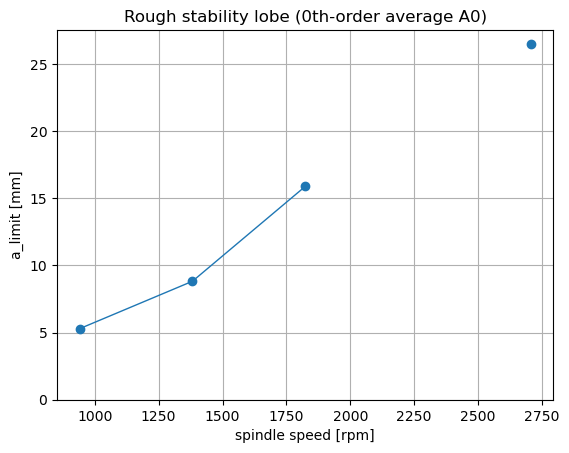

In [17]:
# ---- choose rpm grid (rough) ----
rpm_vals = np.linspace(500, 8000, 18)   # ~18 points, coarse

# ---- choose root search box (rough) ----
root_box = dict(
    sigma_range=(-800, 200),
    omega_range=(0, 9000)
)

# ---- choose depth scan bounds ----
a_max = 30e-3   # 6 mm

# Replace placeholders:
# phi_st, phi_ex from your compute_entry_exit_angles_downmilling
# Ktc_SI, Krc_SI from your Ktc*Krc *1e6
# N_teeth, M2,C2,K2 already set

rpm_vals, a_lim = sweep_lobe_zero_order(
    rpm_values=rpm_vals,
    N_teeth=N_teeth,
    phi_st=phi_st, phi_ex=phi_ex,
    Ktc_SI=Ktc_SI, Krc_SI=Krc_SI,
    M2=M2, C2=C2, K2=K2,
    a_max=a_max,
    root_box=root_box,
    n_scan=18,                 # coarse
    n_grid_scan=(7, 12),       # coarse root seeding
    n_grid_refine=(9, 14),     # modest refine
    refine=True,
    progress_every=3
)

plot_lobe(rpm_vals, a_lim, title="Rough stability lobe (0th-order average A0)")


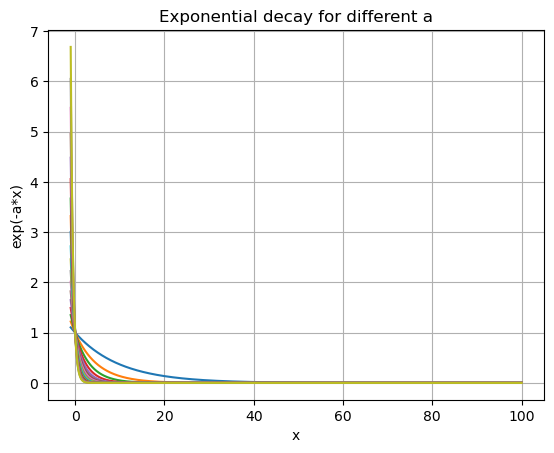

In [24]:
plt.figure()
for a in np.arange(0.1, 2.0, 0.1):
    plt.plot(np.linspace(-1,100,2000) , np.exp(-a*np.linspace(-1,100,2000)), label=f"exp(-{a}*x)")
plt.xlabel("x")
plt.ylabel("exp(-a*x)")
plt.title("Exponential decay for different a")
plt.grid(True)

kx [N/m] = 394784.17604357435
ky [N/m] = 888264.396098042


C:\Users\spadmin\AppData\Local\Temp\ipykernel_51272\4248166052.py:36: RuntimeWarning: overflow encountered in exp
  return self.M*(s**2) + self.C*s + self.K - self.Gamma*(1.0 - np.exp(-s*self.T))
C:\Users\spadmin\AppData\Local\Temp\ipykernel_51272\4248166052.py:36: RuntimeWarning: invalid value encountered in multiply
  return self.M*(s**2) + self.C*s + self.K - self.Gamma*(1.0 - np.exp(-s*self.T))


Rightmost Re(s) among found roots: None
Top 10 roots by Re(s):


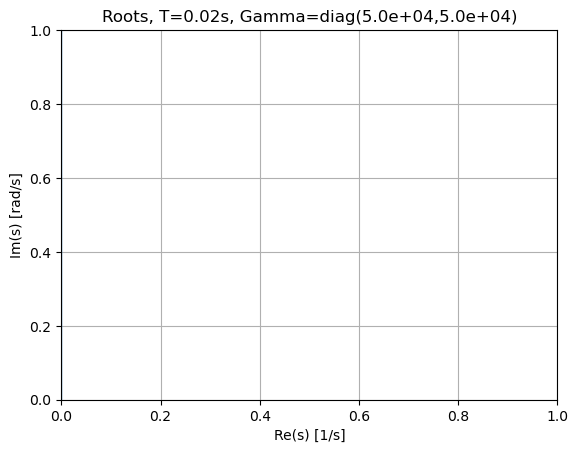

In [30]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.optimize import root

# ---------- Design matrices from desired frequencies ----------
m = 100.0
c = 0.1
fx, fy = 10.0, 15.0

wx, wy = 2*np.pi*fx, 2*np.pi*fy
kx = m*wx**2
ky = m*wy**2

M = np.diag([m, m])
C = np.diag([c, c])
K = np.diag([kx, ky])

print("kx [N/m] =", kx)
print("ky [N/m] =", ky)

# ---------- Delay gain and delay time ----------
Gamma = np.diag([5e4, 5e4])  # try values; increase until instability appears
T = 0.02                    # 20 ms, for example

@dataclass
class DDE2DOF:
    M: np.ndarray
    C: np.ndarray
    K: np.ndarray
    Gamma: np.ndarray
    T: float

    def Delta(self, s: complex) -> np.ndarray:
        return self.M*(s**2) + self.C*s + self.K - self.Gamma*(1.0 - np.exp(-s*self.T))

    def detDelta(self, s: complex) -> complex:
        return la.det(self.Delta(s))

    def det_vec(self, z: np.ndarray) -> np.ndarray:
        s = z[0] + 1j*z[1]
        d = self.detDelta(s)
        return np.array([d.real, d.imag])

model = DDE2DOF(M, C, K, Gamma, T)

# ---------- Root search in a box ----------
def find_roots_in_box(model, sigma_range=(-200, 50), omega_range=(0, 1000),
                      n_grid=(16, 26), tol=1e-10, dedup=1e-1, max_roots=200):
    sigmas = np.linspace(*sigma_range, n_grid[0])
    omegas = np.linspace(*omega_range, n_grid[1])
    roots = []

    def add_root(s):
        for r in roots:
            if abs(s - r) < dedup:
                return
        roots.append(s)

    for sig in sigmas:
        for om in omegas:
            sol = root(model.det_vec, np.array([sig, om]), method="hybr", tol=tol)
            if not sol.success:
                continue
            s = sol.x[0] + 1j*sol.x[1]
            if s.imag < -1e-6:
                continue
            if abs(model.detDelta(s)) < 1e-6:
                add_root(s)
            if len(roots) >= max_roots:
                break

    roots = sorted(roots, key=lambda z: (-z.real, z.imag))
    return np.array(roots, dtype=complex)

def plot_roots(roots, title="Characteristic roots (found in box)"):
    plt.figure()
    if roots.size:
        plt.scatter(roots.real, roots.imag, s=24)
        plt.scatter(roots.real, -roots.imag, s=24, alpha=0.25)
    plt.axvline(0.0, linewidth=1)
    plt.xlabel("Re(s) [1/s]")
    plt.ylabel("Im(s) [rad/s]")
    plt.title(title)
    plt.grid(True)
    plt.show()

a_min = 10.0e-3
a_max = 20e-3
K_min = a_min* Ktc_SI * 0.5
K_max = a_max* Ktc_SI * 0.5

roots = find_roots_in_box(model,
                          sigma_range=(K_min, K_max),
                          omega_range=(0, 8000),
                          n_grid=(18, 30))

print("Rightmost Re(s) among found roots:", np.max(roots.real) if roots.size else None)
print("Top 10 roots by Re(s):")
for r in roots[:10]:
    print(f"s = {r.real:+.3f} {r.imag:+.3f}j")

plot_roots(roots, title=f"Roots, T={T}s, Gamma=diag({Gamma[0,0]:.1e},{Gamma[1,1]:.1e})")


In [31]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def sigma_min_of_Delta(model, s: complex) -> float:
    # smallest singular value of the 2x2 complex matrix Δ(s)
    return la.svd(model.Delta(s), compute_uv=False)[-1]

def grid_minima_candidates(model, sigma_range=(-5, 1), omega_range=(0, 200),
                           n_sigma=120, n_omega=240, take=12):
    sigmas = np.linspace(*sigma_range, n_sigma)
    omegas = np.linspace(*omega_range, n_omega)
    S = np.empty((n_omega, n_sigma), dtype=float)

    for j, w in enumerate(omegas):
        for i, sig in enumerate(sigmas):
            s = sig + 1j*w
            S[j, i] = np.log10(sigma_min_of_Delta(model, s) + 1e-30)

    # pick the best "take" grid points (most negative = smallest σmin)
    flat_idx = np.argsort(S.ravel())[:take]
    cand = []
    for idx in flat_idx:
        j = idx // n_sigma
        i = idx % n_sigma
        cand.append((sigmas[i], omegas[j], S[j, i]))

    return np.array(cand), (sigmas, omegas, S)

def refine_candidate_to_root(model, sigma0, omega0):
    # minimize σmin near candidate; this usually locks onto a true root
    def obj(z):
        sig, w = z
        s = sig + 1j*w
        return sigma_min_of_Delta(model, s)

    res = minimize(obj, x0=np.array([sigma0, omega0]),
                   method="Nelder-Mead",
                   options=dict(maxiter=2000, xatol=1e-10, fatol=1e-12))
    sig, w = res.x
    s = sig + 1j*w
    return s, obj([sig, w]), res.success

def find_roots_via_sigma_min(model, sigma_range=(-5, 1), omega_range=(0, 200),
                             n_sigma=140, n_omega=260, take=18,
                             dedup=1e-3, sigma_min_tol=1e-6):
    cand, (sigmas, omegas, S) = grid_minima_candidates(
        model, sigma_range, omega_range, n_sigma, n_omega, take=take
    )

    roots = []
    for sig0, w0, score in cand:
        s, smin, ok = refine_candidate_to_root(model, sig0, w0)
        if ok and smin < sigma_min_tol:
            # deduplicate
            if all(abs(s-r) > dedup for r in roots):
                roots.append(s)

    roots = sorted(roots, key=lambda z: (-z.real, z.imag))
    return np.array(roots), (sigmas, omegas, S)

def plot_sigma_min_map(sigmas, omegas, S, title="log10 σmin(Δ(s))"):
    plt.figure()
    extent = [sigmas[0], sigmas[-1], omegas[0], omegas[-1]]
    plt.imshow(S, origin="lower", aspect="auto", extent=extent)
    plt.axvline(0.0, linewidth=1)
    plt.xlabel("Re(s)")
    plt.ylabel("Im(s)")
    plt.title(title)
    plt.colorbar(label="log10 σmin")
    plt.show()


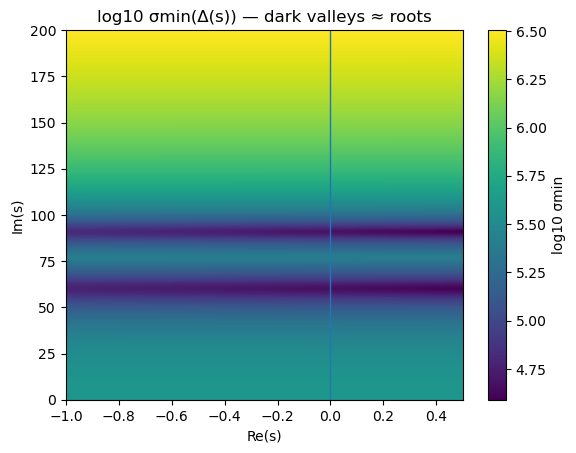

Found candidate roots:
s = +3.605476e+00 +6.022822e+01j, σmin=5.093e-11
s = +2.532355e+00 +9.095205e+01j, σmin=2.769e-10


In [32]:
# roots should be near -c/(2m) ± i*62.8 and ± i*94.2
roots, grid = find_roots_via_sigma_min(
    model,
    sigma_range=(-1.0, 0.5),   # close to the imaginary axis
    omega_range=(0.0, 200.0),  # covers 10Hz and 15Hz (≈63, 94 rad/s)
    n_sigma=160,
    n_omega=320,
    take=24,
    sigma_min_tol=1e-5
)

sigmas, omegas, S = grid
plot_sigma_min_map(sigmas, omegas, S, title="log10 σmin(Δ(s)) — dark valleys ≈ roots")

print("Found candidate roots:")
for r in roots:
    print(f"s = {r.real:+.6e} {r.imag:+.6e}j, σmin={sigma_min_of_Delta(model,r):.3e}")


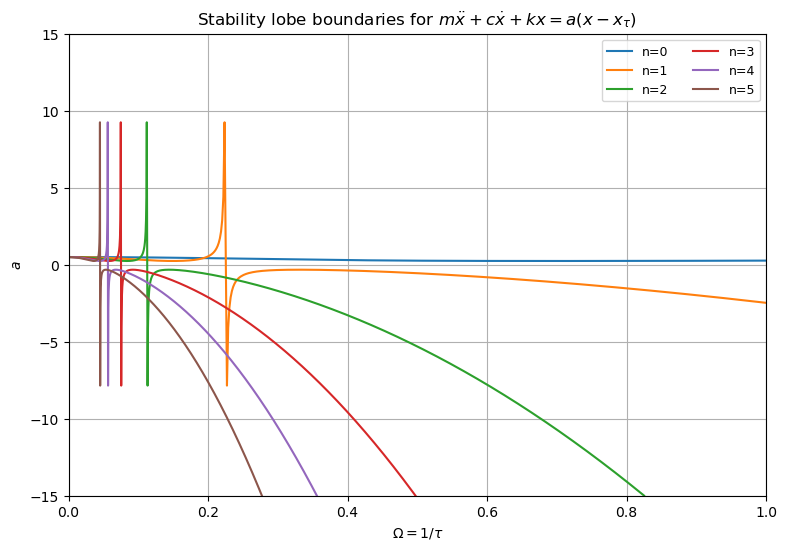

In [1]:

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np


# Stability lobe plot for:
#   m ẍ + c ẋ + k x = a ( x(t) - x(t-τ) )
#
# We parametrize Hopf boundaries by crossing frequency ν>0 and branch index n:
#   tan((ν τ)/2) = (k - m ν^2) / (c ν)
#   τ_n(ν) = (2/ν) * ( arctan((k - m ν^2)/(c ν)) + nπ )
#   a_n(ν) = c ν / sin(ν τ_n)

# ---- parameters (edit these) ----
m = 0.5
c = 0.2
k = 1.0

# Sweep settings
nu_min, nu_max = 1e-3, 20.0     # crossing frequency range ν
N_nu = 6000                     # resolution in ν
N_branches = 6                  # number of lobe branches to draw (n = 0..N_branches-1)

# numerical safety
sin_tol = 1e-6
a_max_plot = 15.0               # clip huge |a| spikes for readability

nus = np.linspace(nu_min, nu_max, N_nu)

plt.figure(figsize=(9, 6))
for n in range(N_branches):
    # phase angle in (-pi/2, pi/2)
    theta = np.arctan2((k - m*nus**2), (c*nus))  # atan((k-mν^2)/(cν)) but robust
    
    # critical delay for branch n
    tau = (2.0 / nus) * (theta + n*np.pi)
    
    # keep only positive delays
    mask = tau > 0
    tau = tau[mask]
    nu = nus[mask]
    
    # compute a on boundary
    phi = nu * tau
    s = np.sin(phi)
    mask2 = np.abs(s) > sin_tol
    tau = tau[mask2]
    nu = nu[mask2]
    s = s[mask2]
    
    a = (c * nu) / s
    
    # x-axis Ω = 1/τ
    Omega = 1.0 / tau
    
    # clip extreme values to keep plot readable
    good = np.isfinite(a) & np.isfinite(Omega) & (np.abs(a) < a_max_plot) & (Omega > 0)
    Omega = Omega[good]
    a = a[good]
    
    # sort by Omega for nicer lines
    idx = np.argsort(Omega)
    Omega = Omega[idx]
    a = a[idx]
    
    plt.plot(Omega, a, linewidth=1.5, label=f"n={n}")

plt.xlabel(r"$\Omega = 1/\tau$")
plt.ylabel(r"$a$")
plt.title(r"Stability lobe boundaries for $m\ddot x + c\dot x + kx = a(x - x_\tau)$")
plt.ylim(-a_max_plot, a_max_plot)
plt.xlim(0, 1)
plt.grid(True)
plt.legend(ncol=2, fontsize=9)
plt.show()



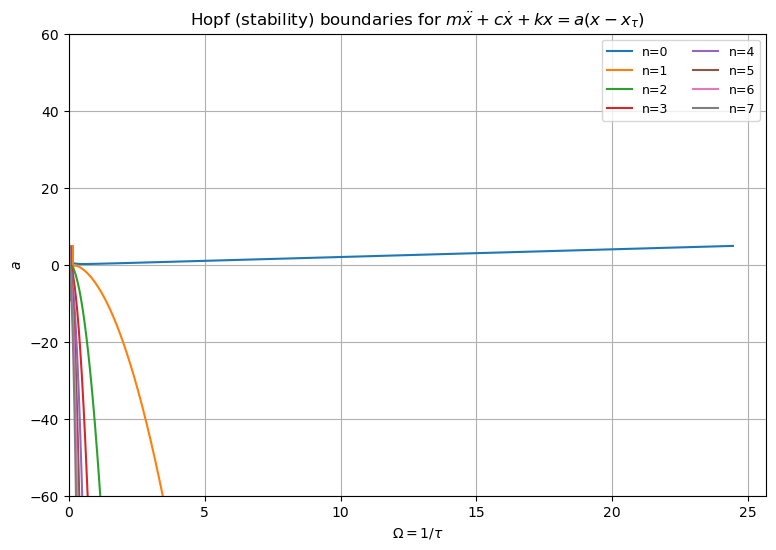

In [2]:
import numpy as np

def load_macro_from_npz(npz_path, axes=(0, 1)):
    data = np.load(npz_path, allow_pickle=False)

    Lambda = data["Lambda_xyz"]  # (3,3)
    Dx     = data["Dx_xyz"]      # (3,3)
    Kx     = data["Kx_xyz"]      # (3,3)

    a0, a1 = axes

    M2 = Lambda[np.ix_([a0, a1], [a0, a1])]
    C2 = Dx[np.ix_([a0, a1], [a0, a1])]
    K2 = Kx[np.ix_([a0, a1], [a0, a1])]

    extras = {k: data[k] for k in data.files if k not in ["Lambda_xyz", "Dx_xyz", "Kx_xyz"]}
    return M2, C2, K2, extras


def compute_entry_exit_angles_downmilling(
    
    r_engagement : float,
    v : float,
    D : float
    
):
    
    # Current tool entry / exit angles: --> https://www.sciencedirect.com/science/article/pii/S0888327020307044#b0160
    # Downmilling setup
    R = D/2
    b =  r_engagement  # radial depth of cut 
    v =  0.0  # We assume full entry of the tool thus distance from the edge is zero. (No partial entry)
    arg = np.clip((R - b) / R , -1.0, 1.0) # np.clip(1.0 - 2.0*b/D, -1.0, 1.0)
    arg1 = np.clip(v / (D/2) ,0.0, 1.0)
    phi_st = np.pi / 2 + np.arcsin(arg)
    phi_ex = np.pi / 2 + np.arccos(arg1)
        
    return phi_st , phi_ex


def mean_directional_matrix_A0(phi_st, phi_ex, Kr, N_teeth):
    """
    Zero-order (average) directional matrix A0.
    Uses Altintas Eq. 4.86 with alpha_xx, alpha_xy, alpha_yx, alpha_yy
    evaluated between entry/exit angles.
    Angles in radians.
    """
    def alpha_xx(phi): return 0.5*( np.cos(2*phi) - 2*Kr*phi + Kr*np.sin(2*phi) )
    def alpha_xy(phi): return 0.5*( -np.sin(2*phi) - 2*phi + Kr*np.cos(2*phi) )
    def alpha_yx(phi): return 0.5*( -np.sin(2*phi) + 2*phi + Kr*np.cos(2*phi) )
    def alpha_yy(phi): return 0.5*( -np.cos(2*phi) - 2*Kr*phi - Kr*np.sin(2*phi) )

    axx = alpha_xx(phi_ex) - alpha_xx(phi_st)
    axy = alpha_xy(phi_ex) - alpha_xy(phi_st)
    ayx = alpha_yx(phi_ex) - alpha_yx(phi_st)
    ayy = alpha_yy(phi_ex) - alpha_yy(phi_st)

    # Eq. 4.86 has scaling N/(2π)
    A0 = (N_teeth/(2*np.pi)) * np.array([[axx, axy],
                                        [ayx, ayy]], dtype=float)
    return A0


def FRF(M, C, K, w):
    jw = 1j*w
    return np.linalg.inv(K - (w**2)*M + jw*C)

def T_period(rpm, N_teeth):
    return 60.0/(rpm*N_teeth)

def chatter_residual(w, M, C, K, A0, T):
    Phi = FRF(M, C, K, w)
    G = A0 @ Phi                      # 2x2 complex
    mu = np.linalg.eigvals(G)         # two complex eigenvalues

    # Convert to lambdas that satisfy det(I - lambda*G)=0  => lambda = 1/mu
    lam = 1.0 / mu

    # choose the "critical" branch; common: the one with smallest |residual|
    res = []
    for l in lam:
        res.append(np.imag(l)*(1 - np.cos(w*T)) - np.real(l)*np.sin(w*T))
    res = np.array(res)

    j = np.argmin(np.abs(res))
    return res[j], lam[j]

def find_omega_c(M, C, K, A0, rpm, N_teeth, w_min, w_max, n_grid=8000):
    T = T_period(rpm, N_teeth)

    ws = np.linspace(w_min, w_max, n_grid)
    rs = np.empty_like(ws, dtype=float)

    # coarse scan
    for i, w in enumerate(ws):
        r, _ = chatter_residual(w, M, C, K, A0, T)
        rs[i] = r

    # find sign changes (brackets)
    idx = np.where(np.sign(rs[:-1]) * np.sign(rs[1:]) < 0)[0]
    if len(idx) == 0:
        # fall back: return best (closest to zero) point
        k = np.argmin(np.abs(rs))
        r, lam = chatter_residual(ws[k], M, C, K, A0, T)
        return ws[k], lam, r

    # refine first bracket with bisection (you can loop all brackets if you want multiple roots)
    a = ws[idx[0]]
    b = ws[idx[0] + 1]
    ra, _ = chatter_residual(a, M, C, K, A0, T)
    rb, _ = chatter_residual(b, M, C, K, A0, T)

    for _ in range(60):
        m = 0.5*(a+b)
        rm, lam_m = chatter_residual(m, M, C, K, A0, T)
        if np.sign(ra) * np.sign(rm) <= 0:
            b, rb = m, rm
        else:
            a, ra = m, rm

    w_c = 0.5*(a+b)
    r_c, lam_c = chatter_residual(w_c, M, C, K, A0, T)
    return w_c, lam_c, r_c


In [24]:
Ktc = 1930.4
Krc = 1159.6

Ktc_SI = Ktc * 1e6     # placeholder; replace with your Ktc * 1e6
Krc_SI = Krc * 1e6     # placeholder; replace with your Krc * 1e6
Kr = Krc_SI / Ktc_SI

N_teeth = 2
rpm_fixed = 400.0
b_radial = 12 # mm
D = 20.0

M2, C2, K2, extras = load_macro_from_npz("./data/linearized_operational_space_xyz.npz", axes=(0, 1)) 
phi_st, phi_ex = compute_entry_exit_angles_downmilling(r_engagement=b_radial, v=0.0, D=D)
A0 = mean_directional_matrix_A0(phi_st, phi_ex, Kr, N_teeth)

# pick a search band (rad/s): e.g. 0..2π*5000 Hz
w_c, lam_c, resid = find_omega_c(
    M2, C2, K2, A0,
    rpm_fixed, N_teeth,
    w_min=2*np.pi*50,
    w_max=2*np.pi*5000,
)

print("omega_c [rad/s] =", w_c)
print("f_c [Hz] =", w_c/(2*np.pi))
print("lambda(omega_c) =", lam_c)
print("residual =", resid)

omega_c [rad/s] = 318.54113141444225
f_c [Hz] = 50.697395642693515
lambda(omega_c) = (16993771.56476423-23749643.564352617j)
residual = 5.21540641784668e-08


In [37]:
import numpy as np

def critical_depth_of_cut(a_lambda, w_c, rpm, N_teeth, Ktc_SI):
    """
    a_lambda: complex lambda at chatter frequency (lam_c)
    w_c: chatter angular frequency [rad/s]
    rpm: spindle speed [rev/min]
    N_teeth: number of teeth
    Ktc_SI: tangential cutting coefficient Kt [N/m^2]
    Returns a_lim in meters.
    """
    T = 60.0/(rpm * N_teeth)

    lam_R = np.real(a_lambda)
    lam_I = np.imag(a_lambda)

    # kappa from either definition (should agree when residual ~ 0)
    kappa = lam_I / lam_R
    print(kappa)

    a_lim = (2*np.pi * lam_R / (N_teeth * Ktc_SI)) * (1 + kappa**2)
    return a_lim

a_lim_m = critical_depth_of_cut(lam_c, w_c, rpm_fixed, N_teeth, Ktc_SI)
print("a_lim [m]  =", a_lim_m)
print("a_lim [mm] =", a_lim_m * 1e3)


-1.3975498890191251
a_lim [m]  = 0.08167275641892786
a_lim [mm] = 81.67275641892786


In [38]:
import numpy as np

def R2(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]], dtype=float)

def rotate_MCK(M, C, K, theta):
    R = R2(theta)
    return R @ M @ R.T, R @ C @ R.T, R @ K @ R.T


def rotate_A0(A0, theta):
    R = R2(theta)
    return R.T @ A0 @ R


-1.3975498890191251
1.1932559020427573
-1.383076559500512
1.1813646907209145
-1.3686987094553695
1.1695283008255606
-1.3544314784283904
1.1577596322659744
-1.3402894005743842
1.1460711819253933
-1.3262864193005766
1.1344750495561045
-1.3124359036369195
1.1229829450736246
-1.298750666031651
1.1116061970445503
-1.2852429812837334
1.100355762168278
-1.2719246063390042
1.0892422355592135
-1.2588068006928728
1.0782758616434955
-1.2459003471586745
1.067466545492243
-1.2332155727771856
1.0568238644218302
-1.2207623696594698
1.0463570797007697
-1.2085502155714491
1.0360751482120403
-1.1965881940849072
1.0259867339293813
-1.1848850141355585
1.0161002190759802
-1.1734490288444281
1.0064237148440285
-1.1622882534742245
0.9969650715640574
-1.1514103824073696
0.9877318882233773
-1.140822805047224
0.9787315212438125
-1.130532620558594
0.9699710924398629
-1.120546651377952
0.9614574960896543
-1.110871455438085
0.9531974050625901
-1.1015133370659893
0.9451972759593704
-1.0924783565268539
0.93746335323

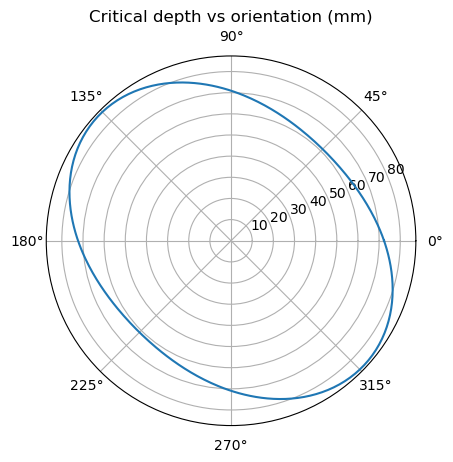

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def R2(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def rotate_A0(A0, theta):
    R = R2(theta)
    return R.T @ A0 @ R

def frf_from_MCK(M, C, K, w):
    return np.linalg.inv(K - (w**2)*M + 1j*w*C)

# ---- fixed chatter frequency ----
w_fixed = w_c     # use your computed chatter frequency

Phi = frf_from_MCK(M2, C2, K2, w_fixed)

theta = np.linspace(0, 2*np.pi, 361)
a_vals = []

for th in theta:
    A0r = rotate_A0(A0, th)

    G = A0r @ Phi
    mu = np.linalg.eigvals(G)
    lam = 1/mu

    # compute depth for both branches
    depths = []
    for l in lam:
        a = critical_depth_of_cut(
            l, w_fixed,
            rpm_fixed, N_teeth,
            Ktc_SI
        )
        if a > 0 and np.isfinite(a):
            depths.append(a)

    # choose smallest positive (physical stability limit)
    if depths:
        a_vals.append(min(depths))
    else:
        a_vals.append(np.nan)

a_vals = np.array(a_vals) * 1e3   # convert to mm

# ---- polar plot ----
plt.figure()
ax = plt.subplot(111, projection='polar')
ax.plot(theta, a_vals)
ax.set_title("Critical depth vs orientation (mm)")
plt.show()


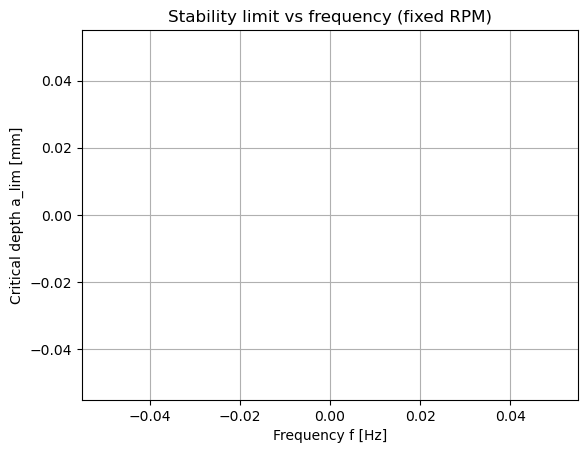

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def frf_from_MCK(M, C, K, w):
    return np.linalg.inv(K - (w**2)*M + 1j*w*C)

def tooth_period(rpm, N_teeth):
    return 60.0/(rpm*N_teeth)

def phase_residual(lam, w, T):
    # Eq. 4.94 residual: λI(1-cos ωT) - λR sin ωT = 0
    lamR, lamI = np.real(lam), np.imag(lam)
    return lamI*(1 - np.cos(w*T)) - lamR*np.sin(w*T)

def kappa_from_delay(w, T):
    denom = (1 - np.cos(w*T))
    # avoid blow-up right at multiples of 2π
    if abs(denom) < 1e-14:
        return np.nan
    return np.sin(w*T)/denom

def a_lim_from_lambda(lam, kappa, N_teeth, Ktc_SI):
    lamR = np.real(lam)
    return -(2*np.pi * lamR / (N_teeth * Ktc_SI)) * (1 + kappa**2)

def stability_curve_a_vs_omega(M, C, K, A0, rpm, N_teeth, Ktc_SI,
                               f_min_hz=50.0, f_max_hz=5000.0, n=6000,
                               resid_tol=1e-2):
    """
    Returns:
      f_hz: frequency grid [Hz]
      a_mm: critical depth [mm] (NaN where phase condition not met well or depth not positive)
      resid: chosen branch residual at each point
    """
    T = tooth_period(rpm, N_teeth)
    f_hz = np.linspace(f_min_hz, f_max_hz, n)
    w = 2*np.pi*f_hz

    a = np.full(n, np.nan, dtype=float)
    resid = np.full(n, np.nan, dtype=float)

    for i, wi in enumerate(w):
        Phi = frf_from_MCK(M, C, K, wi)
        G = A0 @ Phi
        mu = np.linalg.eigvals(G)
        lam = 1.0/mu  # det(I - λ G)=0 convention

        # choose the branch that best satisfies the phase residual at this ω
        r0 = phase_residual(lam[0], wi, T)
        r1 = phase_residual(lam[1], wi, T)
        j = 0 if abs(r0) <= abs(r1) else 1
        r = r0 if j == 0 else r1

        kappa = kappa_from_delay(wi, T)
        if not np.isfinite(kappa):
            continue

        a_m = a_lim_from_lambda(lam[j], kappa, N_teeth, Ktc_SI)

        # keep only physically meaningful + reasonably phase-consistent points
        if (a_m > 0) and (abs(r) < resid_tol):
            a[i] = a_m * 1e3  # mm
            resid[i] = r

    return f_hz, a, resid

# ---- Example usage with your existing variables ----
f_hz, a_mm, resid = stability_curve_a_vs_omega(
    M2, C2, K2, A0,
    rpm=rpm_fixed,
    N_teeth=N_teeth,
    Ktc_SI=Ktc_SI,
    f_min_hz=50,
    f_max_hz=5000,
    n=8000,
    resid_tol=5e-2,   # tighten/loosen depending on how “gappy” the curve looks
)

plt.figure()
plt.plot(f_hz, a_mm)
plt.xlabel("Frequency f [Hz]")
plt.ylabel("Critical depth a_lim [mm]")
plt.title("Stability limit vs frequency (fixed RPM)")
plt.grid(True)
plt.show()


Points plotted: 3076457


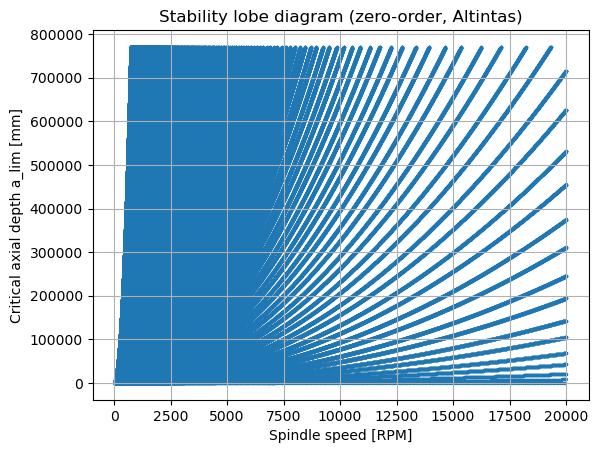

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def frf_from_MCK(M, C, K, w):
    return np.linalg.inv(K - (w**2)*M + 1j*w*C)

def compute_lambda_eigs(M, C, K, A0, w, sign_mode="plain"):
    """
    Returns two complex lambdas at frequency w.
    sign_mode:
      - "plain":  lam = 1/eig(A0*Phi)
      - "negG":   lam = 1/eig(-A0*Phi)
      - "neglam": lam = -1/eig(A0*Phi)
    Use whatever matches your earlier 'fixed it' convention.
    """
    Phi = frf_from_MCK(M, C, K, w)
    G = A0 @ Phi

    if sign_mode == "negG":
        G = -G

    mu = np.linalg.eigvals(G)

    if sign_mode == "neglam":
        lam = -1.0 / mu
    else:
        lam = 1.0 / mu

    return lam

def alim_from_lambda(lam, N_teeth, Ktc_SI):
    """
    a_lim(w) from Altintas:
      a_lim = -(2π λR / (N Kt)) (1 + κ^2), κ = λI/λR
    Returns a_lim [m] or np.nan if invalid.
    """
    lamR = np.real(lam)
    lamI = np.imag(lam)
    if lamR == 0:
        return np.nan
    kappa = lamI / lamR
    a = -(2*np.pi * lamR / (N_teeth * Ktc_SI)) * (1 + kappa**2)
    return a

def rpm_from_kappa_omega(kappa, w, N_teeth, k_lobe):
    """
    Phase relation using:
      kappa = sin(ωT)/(1-cos(ωT)) = cot(ωT/2)
    => ωT/2 = arctan(1/kappa) + kπ
    => ωT   = 2*arctan(1/kappa) + 2kπ

    Then T = (ωT)/ω, and RPM = 60/(N*T) = 60*ω / (N*ωT)
    """
    if not np.isfinite(kappa):
        return np.nan
    # robust angle for arctan(1/kappa)
    base = np.arctan2(1.0, kappa)  # returns in (-π, π)
    omegaT = 2.0*base + 2.0*np.pi*k_lobe

    # need positive delay
    if omegaT <= 0:
        return np.nan

    rpm = 60.0 * w / (N_teeth * omegaT)
    return rpm

def stability_lobes_zero_order(
    M, C, K, A0,
    Ktc_SI, N_teeth,
    f_min_hz=50.0, f_max_hz=5000.0, n_freq=6000,
    rpm_min=50.0, rpm_max=20000.0,
    k_max=200,
    sign_mode="plain",
):
    """
    Returns arrays of points: rpm_points, alim_mm_points, k_points
    """
    ws = 2*np.pi * np.linspace(f_min_hz, f_max_hz, n_freq)

    rpm_pts = []
    a_mm_pts = []
    k_pts = []

    for w in ws:
        lam2 = compute_lambda_eigs(M, C, K, A0, w, sign_mode=sign_mode)

        for lam in lam2:
            lamR = np.real(lam)
            if lamR == 0:
                continue
            kappa = np.imag(lam) / lamR
            a_m = alim_from_lambda(lam, N_teeth, Ktc_SI)
            if not (np.isfinite(a_m) and a_m > 0):
                continue

            # map this (w, kappa) to multiple spindle speeds via lobe number k
            for k in range(k_max + 1):
                rpm = rpm_from_kappa_omega(kappa, w, N_teeth, k)
                if not np.isfinite(rpm):
                    continue
                if rpm_min <= rpm <= rpm_max:
                    rpm_pts.append(rpm)
                    a_mm_pts.append(a_m * 1e3)  # mm
                    k_pts.append(k)

    return np.array(rpm_pts), np.array(a_mm_pts), np.array(k_pts)

# ---------- USAGE ----------
# Choose a frequency band that covers your structural modes
rpm_min, rpm_max = 50, 20000

rpm_pts, a_mm_pts, k_pts = stability_lobes_zero_order(
    M2, C2, K2, A0,
    Ktc_SI=Ktc_SI,
    N_teeth=N_teeth,
    f_min_hz=50,
    f_max_hz=5000,
    n_freq=8000,
    rpm_min=rpm_min,
    rpm_max=rpm_max,
    k_max=200,
    sign_mode="negG",   # <- if your earlier fix needed "negG" or "neglam", set it here
)

print("Points plotted:", len(rpm_pts))

plt.figure()
plt.scatter(rpm_pts, a_mm_pts, s=2)
plt.xlabel("Spindle speed [RPM]")
plt.ylabel("Critical axial depth a_lim [mm]")
plt.title("Stability lobe diagram (zero-order, Altintas)")
plt.grid(True)
plt.show()


In [63]:
import numpy as np
import matplotlib.pyplot as plt

def FRF(M, C, K, w):
    return np.linalg.inv(K - (w**2)*M + 1j*w*C)

def tooth_period(rpm, N_teeth):
    return 60.0/(rpm*N_teeth)

def mean_directional_matrix_A0(phi_st, phi_ex, Kr, N_teeth):
    """
    Zero-order (average) directional matrix A0.
    Uses Altintas Eq. 4.86 with alpha_xx, alpha_xy, alpha_yx, alpha_yy
    evaluated between entry/exit angles.
    Angles in radians.
    """
    def alpha_xx(phi): return 0.5*( np.cos(2*phi) - 2*Kr*phi + Kr*np.sin(2*phi) )
    def alpha_xy(phi): return 0.5*( -np.sin(2*phi) - 2*phi + Kr*np.cos(2*phi) )
    def alpha_yx(phi): return 0.5*( -np.sin(2*phi) + 2*phi + Kr*np.cos(2*phi) )
    def alpha_yy(phi): return 0.5*( -np.cos(2*phi) - 2*Kr*phi - Kr*np.sin(2*phi) )

    axx = alpha_xx(phi_ex) - alpha_xx(phi_st)
    axy = alpha_xy(phi_ex) - alpha_xy(phi_st)
    ayx = alpha_yx(phi_ex) - alpha_yx(phi_st)
    ayy = alpha_yy(phi_ex) - alpha_yy(phi_st)

    # Eq. 4.86 has scaling N/(2π)
    A0 = np.array([[axx, axy],  [ayx, ayy]], dtype=float)
    return A0

def a_lim(lam, N_teeth, Ktc):
    lamR, lamI = np.real(lam), np.imag(lam)

    if lamR == 0:
        return np.nan

    # kappa (either lamI/lamR or from delay, same at the root)
    kappa = lamI/lamR
    a = -(2*np.pi * lamR / (N_teeth * Ktc)) * (1 + kappa**2)
    return a


Ktc = 1930.4 #* 1e6
Krc = 1159.6 # * 1e6
Kr = Krc / Ktc
# Due to definitions Ft = Ktc * b * h and Fr = Kr * Ft. We originally used Fr = Krc * b * h, implying Krc = Kr * Ktc

N_teeth = 2
rpm_fixed = 400.0
b_radial = 12 # mm
a_depth = 5 # mm
D = 20.0

w_c = 2*np.pi*250 # rad/s

M2, C2, K2, extras = load_macro_from_npz("./data/linearized_operational_space_xyz.npz", axes=(0, 1)) 
phi_st, phi_ex = compute_entry_exit_angles_downmilling(r_engagement=b_radial, v=0.0, D=D)
A0 = mean_directional_matrix_A0(phi_st, phi_ex, Kr, N_teeth)
T_p = tooth_period(rpm_fixed, N_teeth)

Phi = FRF(M2, C2, K2, w_c) # 2x2 complex
Phi_0 = A0 @ Phi * 1000
B = 0.5 * a_depth * Ktc * (1 - np.exp(-1j*w_c*T_p)) # *1e-3
argument = np.eye(2) - B * Phi_0
eigs = np.linalg.eigvals(argument)

print("Eigenvalues of (I + A0*Phi*Nabla) at w_c:")
for i, lam in enumerate(eigs):
    print(f"λ[{i}] = {lam.real:+.3e} {lam.imag:+.3e}j, |λ|={abs(lam):.3e}")


Eigenvalues of (I + A0*Phi*Nabla) at w_c:
λ[0] = +9.730e-01 -1.525e-03j, |λ|=9.731e-01
λ[1] = +1.001e+00 +2.707e-02j, |λ|=1.002e+00


Found points: 0


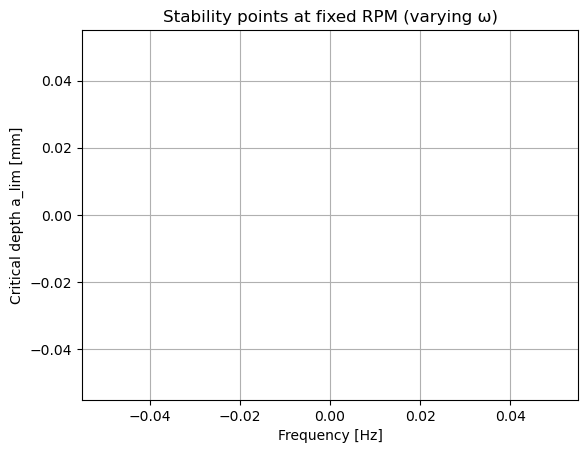

In [64]:
import numpy as np
import matplotlib.pyplot as plt

def FRF(M, C, K, w):
    return np.linalg.inv(K - (w**2)*M + 1j*w*C)

def tooth_period(rpm, N_teeth):
    return 60.0/(rpm*N_teeth)

def phase_residual(lam, w, T):
    lamR, lamI = np.real(lam), np.imag(lam)
    return lamI*(1 - np.cos(w*T)) - lamR*np.sin(w*T)



def stability_points_a_vs_omega(
    M, C, K, A0, rpm, N_teeth, Ktc,
    w_min, w_max, n_grid=20000
):
    """
    Find roots of phase residual for each eigen-branch and return (f_hz, a_lim_mm).
    """
    T = tooth_period(rpm, N_teeth)

    ws = np.linspace(w_min, w_max, n_grid)
    roots_f = []
    roots_a = []

    for branch in [0, 1]:
        # evaluate residual on grid
        r = np.zeros_like(ws)
        for i, w in enumerate(ws):
            Phi = FRF(M, C, K, w)
            G = A0 @ Phi
            mu = np.linalg.eigvals(G)
            lam = 1.0/mu   # if you needed a sign fix, apply it here
            r[i] = phase_residual(lam[branch], w, T)

        # bracket sign changes
        idx = np.where(np.sign(r[:-1]) * np.sign(r[1:]) < 0)[0]

        # bisection refine each root
        for k in idx:
            a_, b_ = ws[k], ws[k+1]
            ra, rb = r[k], r[k+1]

            for _ in range(60):
                m = 0.5*(a_+b_)
                Phi = FRF(M, C, K, m)
                G = A0 @ Phi
                mu = np.linalg.eigvals(G)
                lam = 1.0/mu
                rm = phase_residual(lam[branch], m, T)

                if np.sign(ra)*np.sign(rm) <= 0:
                    b_, rb = m, rm
                else:
                    a_, ra = m, rm

            w_root = 0.5*(a_+b_)

            # compute a_lim at the root
            Phi = FRF(M, C, K, w_root)
            G = A0 @ Phi
            mu = np.linalg.eigvals(G)
            lam = 1.0/mu
            a_lim = alim_from_lambda(lam[branch], w_root, rpm, N_teeth, Ktc)

            if np.isfinite(a_lim) and a_lim > 0:
                roots_f.append(w_root/(2*np.pi))
                roots_a.append(a_lim*1e3)  # mm

    return np.array(roots_f), np.array(roots_a)

# ---- run ----
w_min = 2*np.pi*50
w_max = 2*np.pi*5000

f_pts, a_pts_mm = stability_points_a_vs_omega(
    M2, C2, K2, A0,
    rpm=rpm_fixed,
    N_teeth=N_teeth,
    Ktc=Ktc,          # NOTE: must be unit-consistent with M,C,K and depth
    w_min=w_min, w_max=w_max
)

print("Found points:", len(f_pts))

plt.figure()
plt.scatter(f_pts, a_pts_mm, s=10)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Critical depth a_lim [mm]")
plt.title("Stability points at fixed RPM (varying ω)")
plt.grid(True)
plt.show()


Detected Natural Frequencies: [22.66487137  8.8849931 ] Hz


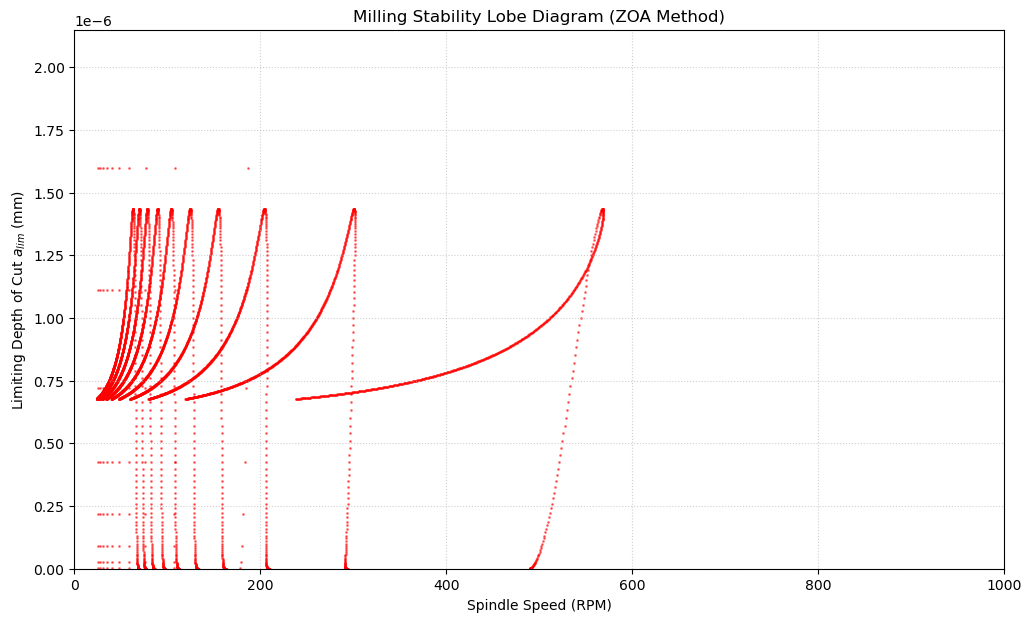

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Identify Natural Frequencies ---
# We must sweep frequencies around the resonance to see the lobes
eigenvalues_sys, _ = np.linalg.eig(np.linalg.inv(M2) @ K2)
wn_rad = np.sqrt(np.real(eigenvalues_sys))
fn_hz = wn_rad / (2 * np.pi)

print(f"Detected Natural Frequencies: {fn_hz} Hz")

# --- 2. Setup Frequency Sweep ---
# Sweep from just below the lowest resonance to significantly above it
f_start = np.min(fn_hz) * 0.9
f_end = np.max(fn_hz) * 1.5
freqs_hz = np.linspace(f_start, f_end, 1000)
w_range = 2 * np.pi * freqs_hz

# --- 3. The Lobe Generation Loop ---
all_rpms = []
all_alim = []

for w_c in w_range:
    # Oriented FRF at current chatter frequency
    Phi = FRF(M2, C2, K2, w_c)
    Phi_0 = A0 @ Phi
    
    # Solve Eigenvalues of the oriented FRF
    eigs = np.linalg.eigvals(Phi_0)
    
    for lam in eigs:
        lamR = lam.real
        lamI = lam.imag
        
        # Stability condition: a_lim must be positive. 
        # In the Altintas ZOA, this requires lamR to be negative.
        if lamR < 0:
            kappa = lamI / lamR
            
            # Limiting depth of cut (a_lim) in meters
            a = -(2 * np.pi * lamR) / (N_teeth * Ktc * (1 + kappa**2))
            
            # Phase shift between inner and outer modulation
            epsilon = 2 * np.pi - 2 * np.arctan(kappa)
            
            # Calculate RPM for multiple lobes (k = 0 is the highest speed lobe)
            for k in range(0, 10): 
                T = (epsilon + 2 * np.pi * k) / w_c
                rpm = 60.0 / (N_teeth * T)
                
                if 0 < rpm < 15000: # Filter for a reasonable spindle range
                    all_rpms.append(rpm)
                    all_alim.append(a)

# --- 4. Plotting ---
plt.figure(figsize=(12, 7))
# We use scatter because the points are generated by frequency, not by RPM order
plt.scatter(all_rpms, np.array(all_alim) * 1000, s=1, color='red', alpha=0.5)

plt.title("Milling Stability Lobe Diagram (ZOA Method)")
plt.xlabel("Spindle Speed (RPM)")
plt.ylabel("Limiting Depth of Cut $a_{lim}$ (mm)")
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.xlim(0, 1000)
plt.ylim(0, np.percentile(all_alim, 95) * 1000 * 1.5) # Dynamic scale for clarity
plt.show()

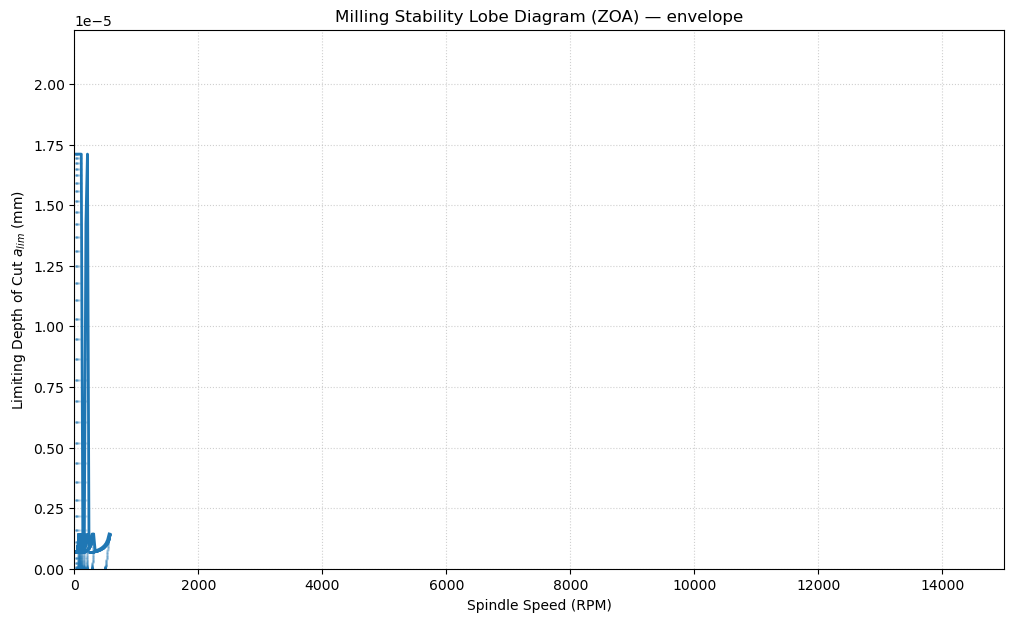

In [66]:
# After you fill all_rpms and all_alim ...

rpms = np.array(all_rpms)
alim_mm = np.array(all_alim) * 1000.0  # mm

# Bin RPM and take envelope (max a_lim in each bin)
rpm_min, rpm_max = 0, 15000
bin_width = 25  # RPM (adjust)
bins = np.arange(rpm_min, rpm_max + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

envelope = np.full(len(bin_centers), np.nan)

for i in range(len(bin_centers)):
    mask = (rpms >= bins[i]) & (rpms < bins[i+1])
    if np.any(mask):
        envelope[i] = np.max(alim_mm[mask])

plt.figure(figsize=(12, 7))
plt.scatter(rpms, alim_mm, s=1, alpha=0.15)              # faint cloud
plt.plot(bin_centers, envelope, linewidth=2)             # envelope
plt.title("Milling Stability Lobe Diagram (ZOA) — envelope")
plt.xlabel("Spindle Speed (RPM)")
plt.ylabel(r"Limiting Depth of Cut $a_{lim}$ (mm)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.xlim(0, 15000)
plt.ylim(0, np.nanpercentile(envelope, 95) * 1.3)
plt.show()
